<a href="https://colab.research.google.com/github/Lingeshkumar24-code/deep-learning/blob/main/ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Checking GPU
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Install required libraries
!pip install kaggle
!pip install seaborn

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [6]:
!pip install -q kaggle

In [7]:
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:03<00:00, 168MB/s]



In [8]:
import zipfile #Unzipping the dataset

with zipfile.ZipFile("gtsrb-german-traffic-sign.zip","r") as zip_ref:
    zip_ref.extractall("/content/GTSRB")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [10]:
train_path="/content/GTSRB/Train"

In [11]:
#Dataset Preprocessing
IMAGE_SIZE=(224,224)

BATCH_SIZE=32

train_datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator=train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    subset="training",
    class_mode="categorical"
)

validation_generator=train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    subset="validation",
    class_mode="categorical"
)

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


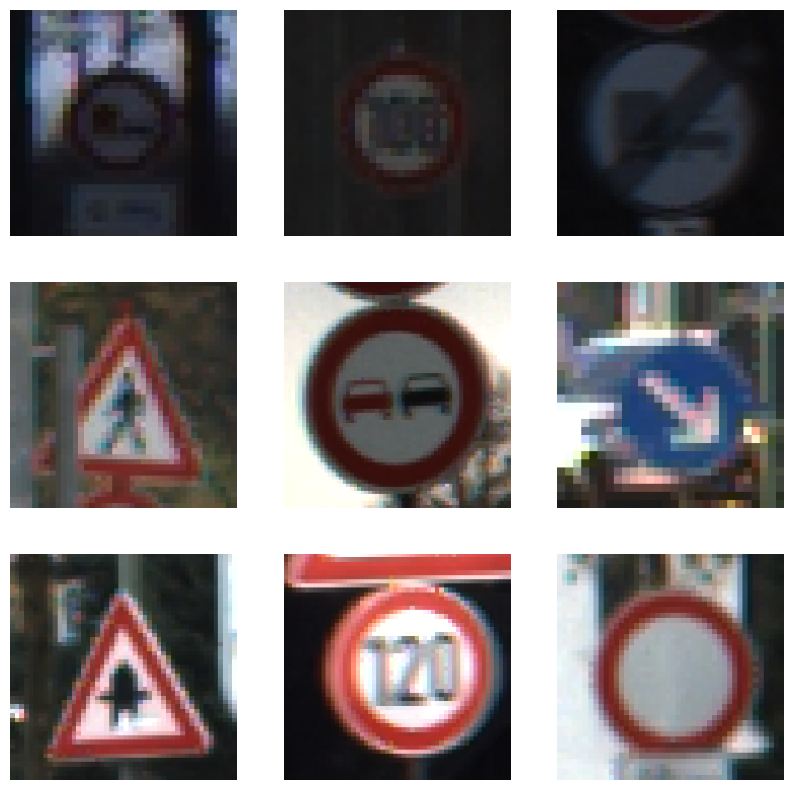

In [12]:
#Diplay sample images
images,labels=next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [13]:
#Bild Resnet 50

In [14]:
base_model=ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable=False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
#Creating model
x=base_model.output

x=GlobalAveragePooling2D()(x)

x=Dropout(0.5)(x)

x=Dense(256,activation="relu")(x)

output=Dense(43,activation="softmax")(x)

model=Model(inputs=base_model.input,
            outputs=output)

In [16]:
#Compiling model

In [17]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,123,307 (92.02 MB)

 Trainable params: 535,595 (2.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
history=model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=2
)

Epoch 1/2
981/981 ━━━━━━━━━━━━━━━━━━━━ 137s 124ms/step - accuracy: 0.0605 - loss: 3.5739 - val_accuracy: 0.0573 - val_loss: 3.4328
Epoch 2/2
981/981 ━━━━━━━━━━━━━━━━━━━━ 120s 122ms/step - accuracy: 0.0802 - loss: 3.4546 - val_accuracy: 0.0937 - val_loss: 3.3681


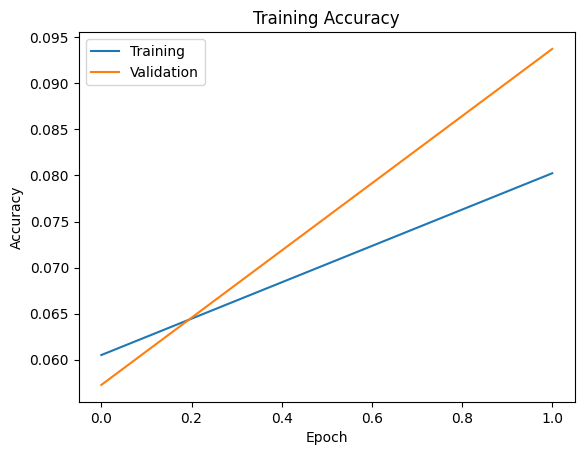

In [20]:
#Accuracy Graph
plt.plot(history.history["accuracy"],label="Training")

plt.plot(history.history["val_accuracy"],label="Validation")

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.show()

In [ ]:
#Loss graph

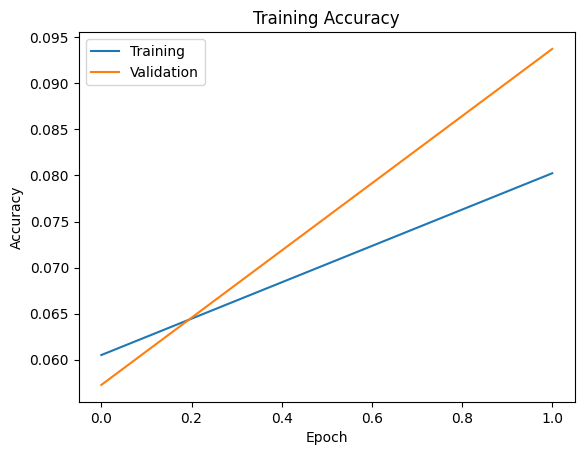

In [21]:
plt.plot(history.history["accuracy"],label="Training")

plt.plot(history.history["val_accuracy"],label="Validation")

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.show()

In [22]:
#Evaluate model
loss,accuracy=model.evaluate(validation_generator)

print("Validation Loss :",loss)

print("Validation Accuracy :",accuracy)

246/246 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.0937 - loss: 3.3681
Validation Loss : 3.3680622577667236
Validation Accuracy : 0.09373804181814194


In [ ]:
#Saving the model

In [25]:
from tensorflow.keras.models import load_model

model.save("TrafficSign_ResNet50.keras")
model = load_model("TrafficSign_ResNet50.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


In [26]:
#Predict new images

Class directories found in /content/GTSRB/Train/: ['12', '18', '11', '17', '41', '4', '2', '6', '31', '25', '7', '13', '33', '34', '1', '42', '35', '23', '32', '30', '40', '38', '9', '10', '20', '29', '37', '5', '22', '27', '16', '0', '26', '36', '15', '28', '19', '39', '8', '14', '24', '3', '21']
Attempting to list contents of: /content/GTSRB/Train/0
Images found in 0: ['00000_00005_00008.png', '00000_00004_00017.png', '00000_00001_00004.png', '00000_00002_00015.png', '00000_00006_00028.png'] (showing first 5)
Constructed image_path: /content/GTSRB/Train/0/00000_00005_00008.png
Image loaded successfully from /content/GTSRB/Train/0/00000_00005_00008.png using PIL.


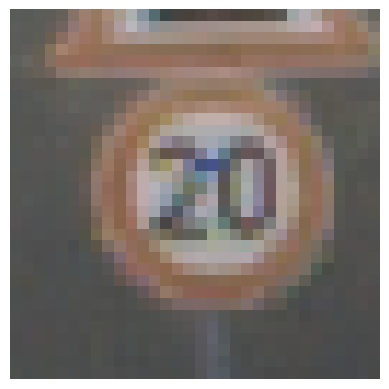

NameError: name 'model' is not defined

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image # Import PIL
import os

# Let's inspect the contents of the parent training directory to find the correct class folders
train_base_dir = "/content/GTSRB/Train/"

if os.path.exists(train_base_dir):
    class_dirs = [d for d in os.listdir(train_base_dir) if os.path.isdir(os.path.join(train_base_dir, d))]
    print(f"Class directories found in {train_base_dir}: {class_dirs}")
    if class_dirs:
        # Assuming the first class directory (e.g., '00000') contains images
        # Let's pick the first one from the list, or a specific one if known to exist.
        selected_class_dir = sorted(class_dirs)[0] # Sort to get '00000' if it exists
        print(f"Attempting to list contents of: {os.path.join(train_base_dir, selected_class_dir)}")
        images_in_class_dir = [f for f in os.listdir(os.path.join(train_base_dir, selected_class_dir)) if f.endswith(('.ppm', '.png', '.jpg'))]
        print(f"Images found in {selected_class_dir}: {images_in_class_dir[:5]} (showing first 5)") # show first few images

        if images_in_class_dir:
            # Construct image_path using the first image found in the selected class directory
            image_path = os.path.join(train_base_dir, selected_class_dir, images_in_class_dir[0])
            print(f"Constructed image_path: {image_path}")
        else:
            image_path = None
            print(f"No image files found in {os.path.join(train_base_dir, selected_class_dir)}")
    else:
        image_path = None
        print(f"No class directories found in {train_base_dir}")
else:
    image_path = None
    print(f"Error: Training base directory not found at {train_base_dir}")


image = None
if image_path:
    try:
        pil_image = Image.open(image_path)
        image = np.array(pil_image) # Convert PIL image to numpy array (RGB)
        # If image has an alpha channel, remove it
        if image.shape[2] == 4:
            image = image[:, :, :3]
        print(f"Image loaded successfully from {image_path} using PIL.")
    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
        image = None
    except Exception as e:
        print(f"Error loading image with PIL: {e}")
        image = None

if image is None:
    print("Could not load image. Please check the image path and file integrity.")
else:
    # The image is now in RGB format (from PIL), so cv2.cvtColor(image, cv2.COLOR_BGR2RGB) is not needed

    plt.imshow(image)
    plt.axis("off")
    plt.show()

    image = cv2.resize(image, (224, 224))

    image = image.astype("float32") / 255.0

    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    print("Predicted Class :", predicted_class)
    print("Confidence :", confidence)

Model loaded successfully within this cell.
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


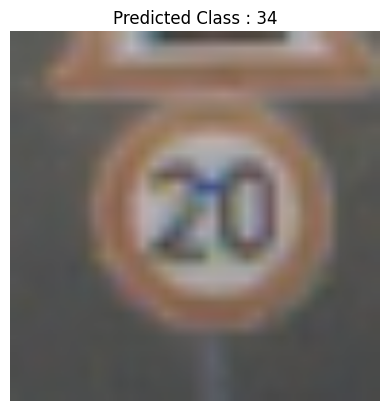

In [6]:
#Show prediction on images
import cv2
import numpy as np # Explicitly import numpy
import matplotlib.pyplot as plt # Explicitly import matplotlib.pyplot
from tensorflow.keras.models import load_model
from PIL import Image # Import PIL for fallback image loading

# Load the model directly to ensure it's defined for this cell's execution.
# This assumes "TrafficSign_ResNet50.keras" has been saved earlier.
try:
    model = load_model("TrafficSign_ResNet50.keras")
    print("Model loaded successfully within this cell.")
except Exception as e:
    print(f"Error loading model: {e}. Please ensure 'TrafficSign_ResNet50.keras' exists and dependencies are met.")
    # If the model cannot be loaded, the rest of the cell cannot proceed.
    exit() # Stop execution if model loading fails

# The image_path variable is assumed to be defined by prior cells (e.g., kjYFaXhLBY6x).
image = cv2.imread(image_path)

# Add a check for cv2.imread success as it can return None if file is not found/readable
if image is None:
    print(f"Error: cv2.imread failed to load image from {image_path}. "
          "This might be due to the file format or path. "
          "Attempting with PIL as fallback.")
    try:
        pil_image = Image.open(image_path)
        image = np.array(pil_image) # Convert PIL image to numpy array (RGB)
        if image.shape[2] == 4:
            image = image[:, :, :3] # Remove alpha channel if present
        print(f"Image loaded successfully using PIL as fallback from {image_path}.")
    except Exception as e_pil:
        print(f"PIL fallback also failed: {e_pil}. Cannot proceed with image processing.")
        exit() # Stop execution if image cannot be loaded by either method

if image is not None: # Ensure image is loaded before processing
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    display_image = cv2.resize(image,(300,300))

    test = cv2.resize(image,(224,224))

    test = test/255.0

    test = np.expand_dims(test,axis=0)

    prediction = model.predict(test)

    predicted_class = np.argmax(prediction)

    plt.imshow(display_image)
    plt.title(f"Predicted Class : {predicted_class}")
    plt.axis("off")
    plt.show()
